# MTAOS Z4 (Focus / Defocus) Trends — Nightly Timeline and AOS FWHM Correlation

Queries `lsst.sal.MTAOS.logevent_wavefrontError` from the EFD to retrieve
per-cycle Z4 (Noll defocus, `nollZernikeValues0`, units: µm) measured by the
four corner wavefront sensors. Joins to ConsDB `visit1_quicklook` via
`visitId` to correlate with `aos_fwhm`.

### What this notebook produces
1. **Nightly median Z4 timeline** — night-by-night median and IQR across all corner sensors.
2. **Nightly Z4 RMS (intra-night spread)** — how much focus varies within each night.
3. **Per-sensor nightly timeline** — individual tracks for the four corner sensors.
4. **Z4 vs `aos_fwhm` scatter** — density plots of the defocus–FWHM relationship.


## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlalchemy

from astropy.time import Time, TimeDelta
import astropy.units as u
from lsst_efd_client import EfdClient

%matplotlib inline

## Configuration

In [2]:
# ── Time window ───────────────────────────────────────────────────────────────
t_end   = Time("2026-06-08T12:00:00", scale="utc")
t_start = t_end - TimeDelta(90 * u.day)
print(f"EFD window: {t_start.iso}  →  {t_end.iso}")

day_obs_start = int(t_start.strftime("%Y%m%d"))
day_obs_end   = int(t_end.strftime("%Y%m%d"))
print(f"day_obs range: {day_obs_start} – {day_obs_end}")

# ── EFD ───────────────────────────────────────────────────────────────────────
EFD_ALIAS = "usdf_efd"
WFE_TOPIC = "lsst.sal.MTAOS.logevent_wavefrontError"
N_NOLL_VALUES = 25        # Z4–Z28
NOLL_OFFSET   = 4         # first Noll index

# ── Corner sensor ID → label ──────────────────────────────────────────────────
# Each corner raft has two wavefront sensors: SW0 (odd ID) and SW1 (even ID).
SENSOR_LABELS = {
    191: "R00 SW0",  192: "R00 SW1",
    195: "R04 SW0",  196: "R04 SW1",
    199: "R40 SW0",  200: "R40 SW1",
    203: "R44 SW0",  204: "R44 SW1",
}
SENSOR_COLORS = {
    191: "steelblue",   192: "steelblue",
    195: "tomato",      196: "tomato",
    199: "mediumseagreen", 200: "mediumseagreen",
    203: "darkorchid",  204: "darkorchid",
}
# SW0 = solid line, SW1 = dashed
SENSOR_LS = {sid: ("-" if sid % 2 == 1 else "--") for sid in SENSOR_LABELS}

# ── ConsDB / PostgreSQL ───────────────────────────────────────────────────────
PGPASS_FILE = os.path.expanduser("~/.lsst/postgres-credentials.txt")
CONSDB_HOST = "usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu"
CONSDB_DB   = "exposurelog"
CONSDB_USER = "usdf"
SCHEMA      = "cdb_lsstcam"

def load_pgpass(path, host, database, user):
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(":")
            if len(parts) >= 5 and parts[0] == host and parts[2] == database and parts[3] == user:
                return ":".join(parts[4:])
    raise ValueError(f"No credentials for {user}@{host}/{database}")

db_pass = load_pgpass(PGPASS_FILE, CONSDB_HOST, CONSDB_DB, CONSDB_USER)
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{CONSDB_USER}:{db_pass}@{CONSDB_HOST}/{CONSDB_DB}",
    connect_args={"connect_timeout": 30},
)

def consdb_query(sql):
    with engine.connect() as conn:
        return pd.read_sql_query(sqlalchemy.text(sql), conn)

print("Config ready.")
# ── Parquet cache ────────────────────────────────────────────────────────────
CACHE_FILE      = "../data/z4_wfe.parquet"
GRAD_CACHE_FILE = "../data/z4_m1m3_gradients.parquet"
FORCE_REFETCH   = False   # True → ignore cache, re-fetch everything


EFD window: 2026-03-10 12:00:00.000  →  2026-06-08 12:00:00.000
day_obs range: 20260310 – 20260608
Config ready.


## 1. Fetch Z4 from EFD

Each row of `logevent_wavefrontError` is one AOS cycle measurement for one
corner sensor. `nollZernikeValues0` = Z4 (Noll defocus) in **µm**.
`visitId` links back to ConsDB exposures.


In [3]:
import pathlib as _pl

efd_client = EfdClient(EFD_ALIAS)
print(f"Connected to EFD alias: {EFD_ALIAS}")

_from_cache = False
if not FORCE_REFETCH and _pl.Path(CACHE_FILE).exists():
    df_wfe = pd.read_parquet(CACHE_FILE)
    df_wfe["z4_um"] = pd.to_numeric(df_wfe["z4_um"], errors="coerce")
    _from_cache = True
    print(f"\u2713 Loaded {len(df_wfe)} EFD rows from cache: {CACHE_FILE}")
    print(f"Time range: {df_wfe.index.min()}  \u2192  {df_wfe.index.max()}")
    print(f"Unique sensorIds: {sorted(df_wfe['sensorId'].unique())}")
    print(f"Z4 range: {df_wfe['z4_um'].min():.3f} to {df_wfe['z4_um'].max():.3f} \u00b5m")
else:
    noll_val_fields = [f"nollZernikeValues{i}" for i in range(N_NOLL_VALUES)]
    df_wfe = await efd_client.select_time_series(
        WFE_TOPIC,
        fields=["sensorId", "visitId"] + noll_val_fields,
        start=t_start,
        end=t_end,
    )
    print(f"Rows returned: {len(df_wfe)}")
    if df_wfe.empty:
        print("No data \u2014 widen the time window or check EFD alias.")
    else:
        print(f"Time range: {df_wfe.index.min()}  \u2192  {df_wfe.index.max()}")
        print(f"Unique sensorIds: {sorted(df_wfe['sensorId'].unique())}")
        df_wfe["z4_um"] = pd.to_numeric(df_wfe["nollZernikeValues0"], errors="coerce")
        print(f"Z4 range: {df_wfe['z4_um'].min():.3f} to {df_wfe['z4_um'].max():.3f} \u00b5m")
        display(df_wfe[["sensorId", "visitId", "z4_um"]].head(6))
        df_wfe[["sensorId", "visitId", "z4_um"]].to_parquet(CACHE_FILE)
        print(f"\u2713 Saved {len(df_wfe)} rows \u2192 {CACHE_FILE}")


Connected to EFD alias: usdf_efd
✓ Loaded 93940 EFD rows from cache: ../data/z4_wfe.parquet
Time range: 2026-03-11 00:24:41.539403+00:00  →  2026-06-08 10:37:03.797264+00:00
Unique sensorIds: [np.int64(191), np.int64(192), np.int64(195), np.int64(196), np.int64(199), np.int64(200), np.int64(203), np.int64(204)]
Z4 range: -10.177 to 6.445 µm


## 2. Fetch `aos_fwhm` from ConsDB

Pull `visit_id` and image-quality metrics from `visit1_quicklook` for the
same window so we can join on `visitId`.


In [4]:
sql = (
    f"SELECT e.day_obs, q.visit_id, q.aos_fwhm, q.donut_blur_fwhm, "
    f"q.psf_sigma_median, q.seeing_zenith_500nm_median, e.obs_start "
    f"FROM {SCHEMA}.exposure e "
    f"JOIN {SCHEMA}.visit1_quicklook q "
    f"ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num "
    f"WHERE e.img_type = 'science' "
    f"AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end} "
    f"AND q.aos_fwhm IS NOT NULL "
    f"ORDER BY e.day_obs, e.seq_num"
)
df_consdb = consdb_query(sql)

for c in ["aos_fwhm", "donut_blur_fwhm", "psf_sigma_median", "seeing_zenith_500nm_median"]:
    df_consdb[c] = pd.to_numeric(df_consdb[c], errors="coerce")
df_consdb["obs_start"] = pd.to_datetime(df_consdb["obs_start"], utc=True)

print(f"ConsDB rows: {len(df_consdb)}")
display(df_consdb.head(4))

ConsDB rows: 35741


,day_obs,visit_id,aos_fwhm,donut_blur_fwhm,psf_sigma_median,seeing_zenith_500nm_median,obs_start
0,20260311,2026031100014,0.380317,0.670709,1.648323,NaN,2026-03-12 00:01:38.317000+00:00
1,20260311,2026031100015,0.407420,0.691540,1.564574,NaN,2026-03-12 00:02:14.867000+00:00
2,20260311,2026031100016,0.367806,0.759791,1.644752,NaN,2026-03-12 00:02:51.042000+00:00
3,20260311,2026031100017,0.379583,0.677848,1.592341,NaN,2026-03-12 00:03:28.522000+00:00


## 3. Compute Nightly Z4 Statistics

Aggregate Z4 per night (day_obs) across all four corner sensors:
- **median** — typical defocus each night
- **IQR** (25th–75th pct) — spread / robustness indicator  
- **RMS** (`std`) — intra-night variability


In [5]:
if df_wfe.empty:
    print("No EFD data.")
else:
    # day_obs = evening date: noon-UTC boundary
    ts = df_wfe.index
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    df_wfe["day_obs"] = (
        (ts - pd.Timedelta(hours=12))
        .strftime("%Y%m%d")
        .astype(int)
    )

    df_nightly = (
        df_wfe.groupby("day_obs")["z4_um"]
        .agg(
            n="count",
            z4_median=lambda x: x.median(),
            z4_q25=lambda x: x.quantile(0.25),
            z4_q75=lambda x: x.quantile(0.75),
            z4_rms="std",
            z4_mean="mean",
        )
        .reset_index()
    )
    df_nightly["date"] = pd.to_datetime(df_nightly["day_obs"].astype(str), format="%Y%m%d")
    df_nightly["z4_iqr"] = df_nightly["z4_q75"] - df_nightly["z4_q25"]

    print(f"Nights with Z4 data: {len(df_nightly)}")
    display(df_nightly[["day_obs", "n", "z4_median", "z4_rms", "z4_iqr"]].round(4).head(10))

    # ── Z4 → arcsec conversion (galsim, LSST aperture 8.36m, obs=0.612) ──────
    # Z4 (defocus) gradient RMS → FWHM contribution: 0.7545 arcsec/µm
    Z4_ARCSEC_PER_UM = 0.7545   # arcsec per µm of Z4 wavefront error

    df_nightly["z4_median_arcsec"] = df_nightly["z4_median"] * Z4_ARCSEC_PER_UM
    df_nightly["z4_q25_arcsec"]    = df_nightly["z4_q25"]    * Z4_ARCSEC_PER_UM
    df_nightly["z4_q75_arcsec"]    = df_nightly["z4_q75"]    * Z4_ARCSEC_PER_UM
    df_nightly["z4_rms_arcsec"]    = df_nightly["z4_rms"]    * Z4_ARCSEC_PER_UM
    print(f"Z4 conversion: {Z4_ARCSEC_PER_UM} arcsec/µm")


Nights with Z4 data: 69


,day_obs,n,z4_median,z4_rms,z4_iqr
0,20260310,1352,-0.2032,0.2737,0.1532
1,20260311,3208,-0.1942,0.2251,0.1317
2,20260312,2476,-0.2071,0.2214,0.1745
3,20260313,1176,-0.1989,0.6686,0.8186
4,20260314,3176,-0.1927,0.1609,0.1372
5,20260315,1416,-0.1902,0.2026,0.1331
6,20260316,2408,-0.2082,0.2978,0.1464
7,20260317,1440,-0.1756,0.2289,0.1947
8,20260318,3576,-0.2195,0.2600,0.2151
9,20260319,1064,-0.2958,0.3856,0.2951


Z4 conversion: 0.7545 arcsec/µm


## 4. Nightly Z4 Median Timeline (all sensors combined)

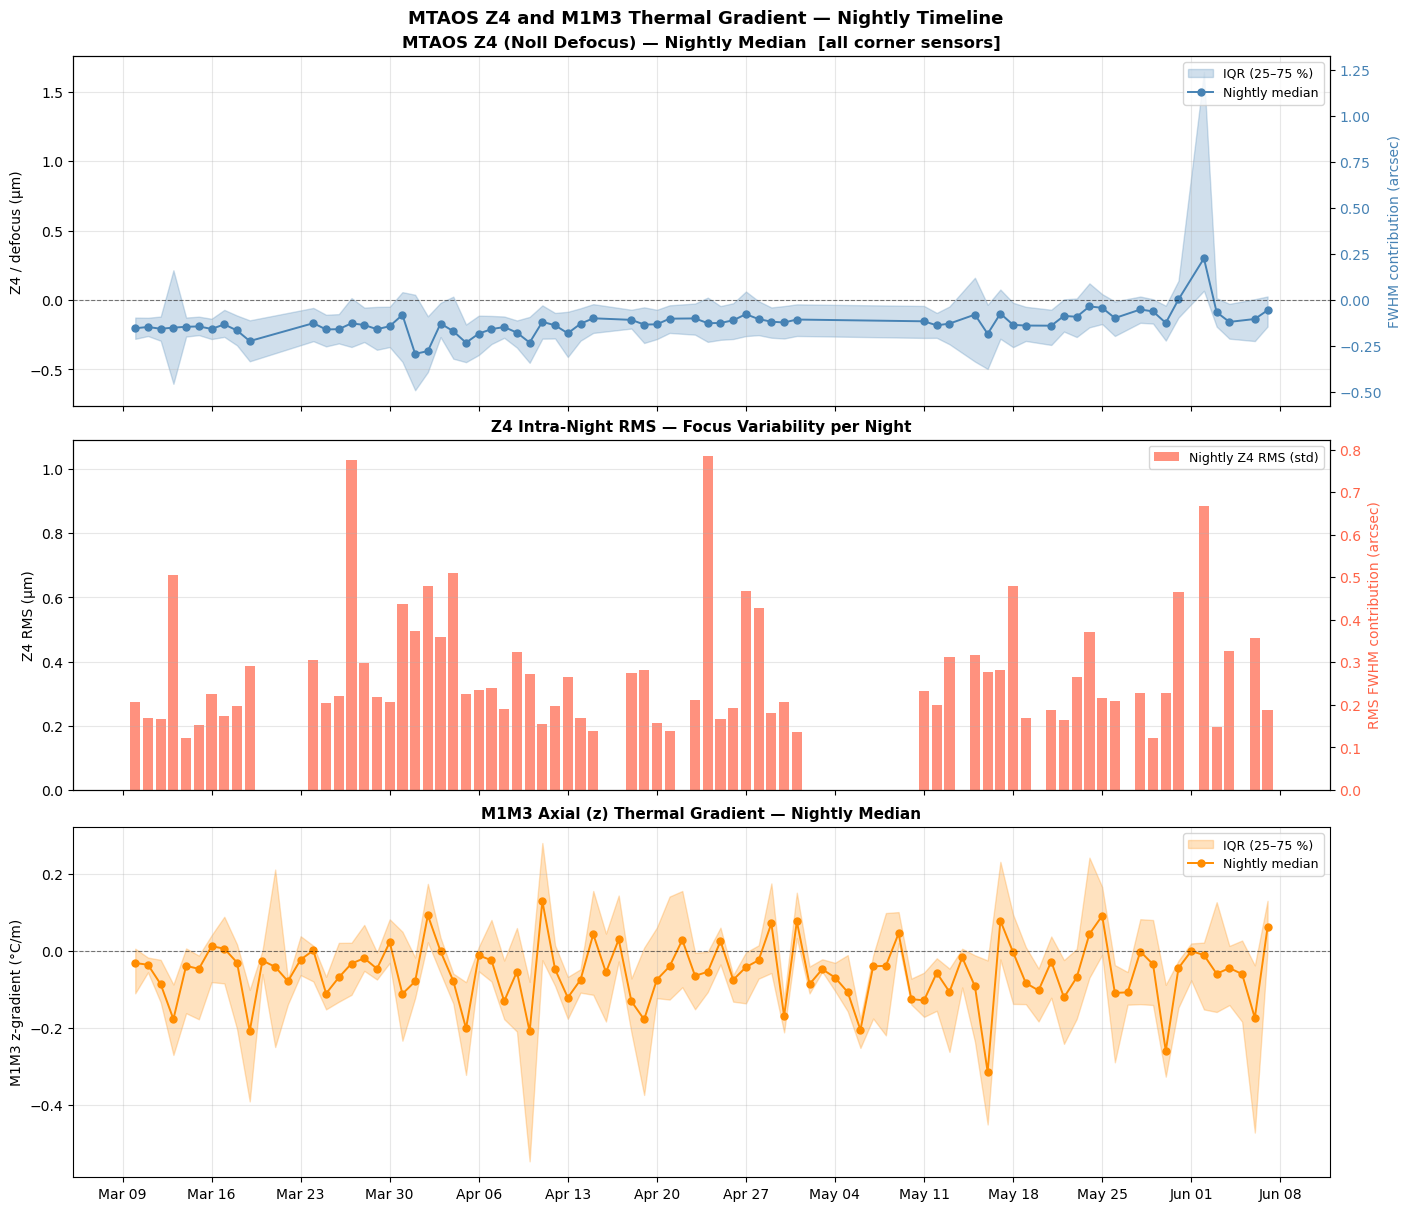

In [7]:
if df_wfe.empty or 'date' not in df_nightly.columns:
    print('No data to plot.')
else:
    # ── Build nightly z-gradient summary (if gradient data available) ─────────
    has_nightly_grad = 'df_grad' in globals() and df_grad is not None
    if has_nightly_grad:
        df_grad_night = df_grad.copy()
        ts_g = df_grad_night.index
        if ts_g.tzinfo is None:
            ts_g = ts_g.tz_localize('UTC')
        df_grad_night['day_obs'] = (
            (ts_g - pd.Timedelta(hours=12)).strftime('%Y%m%d').astype(int)
        )
        df_grad_nightly = (
            df_grad_night.groupby('day_obs')['z_gradient']
            .agg(z_grad_median='median', z_grad_q25=lambda x: x.quantile(0.25),
                 z_grad_q75=lambda x: x.quantile(0.75))
            .reset_index()
        )
        df_grad_nightly['date'] = pd.to_datetime(
            df_grad_nightly['day_obs'].astype(str), format='%Y%m%d'
        )

    nrows = 3 if has_nightly_grad else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(14, 4 * nrows),
                             sharex=True, constrained_layout=True)

    # ── Panel 1: Z4 median in µm with secondary arcsec axis ───────────────────
    ax = axes[0]
    ax.fill_between(df_nightly['date'], df_nightly['z4_q25'], df_nightly['z4_q75'],
                    alpha=0.25, color='steelblue', label='IQR (25–75 %)')
    ax.plot(df_nightly['date'], df_nightly['z4_median'],
            marker='o', ms=5, lw=1.4, color='steelblue', label='Nightly median')
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('Z4 / defocus (µm)')
    ax.set_title('MTAOS Z4 (Noll Defocus) — Nightly Median  [all corner sensors]',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    ax2.set_ylim(np.array(ax.get_ylim()) * Z4_ARCSEC_PER_UM)
    ax2.set_ylabel('FWHM contribution (arcsec)', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')

    # ── Panel 2: Z4 intra-night RMS ───────────────────────────────────────────
    ax = axes[1]
    ax.bar(df_nightly['date'], df_nightly['z4_rms'],
           width=0.8, color='tomato', alpha=0.7, label='Nightly Z4 RMS (std)')
    ax.set_ylabel('Z4 RMS (µm)')
    ax.set_title('Z4 Intra-Night RMS — Focus Variability per Night',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    ax2b = ax.twinx()
    ax2b.set_ylim(np.array(ax.get_ylim()) * Z4_ARCSEC_PER_UM)
    ax2b.set_ylabel('RMS FWHM contribution (arcsec)', color='tomato')
    ax2b.tick_params(axis='y', labelcolor='tomato')

    # ── Panel 3: nightly z-gradient (optional) ────────────────────────────────
    if has_nightly_grad:
        ax = axes[2]
        ax.fill_between(df_grad_nightly['date'],
                        df_grad_nightly['z_grad_q25'], df_grad_nightly['z_grad_q75'],
                        alpha=0.25, color='darkorange', label='IQR (25–75 %)')
        ax.plot(df_grad_nightly['date'], df_grad_nightly['z_grad_median'],
                marker='o', ms=5, lw=1.4, color='darkorange', label='Nightly median')
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_ylabel('M1M3 z-gradient (°C/m)')
        ax.set_title('M1M3 Axial (z) Thermal Gradient — Nightly Median',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.xticks(rotation=30, ha='right')
    fig.suptitle('MTAOS Z4 and M1M3 Thermal Gradient — Nightly Timeline',
                 fontsize=13, fontweight='bold')
    plt.show()

## 5. Nightly Z4 RMS (Intra-Night Spread)

*(Combined into the timeline above.)*

In [8]:
# RMS timeline now part of cell above — kept for compatibility.
pass

## 6. Per-Sensor Nightly Z4 Timeline

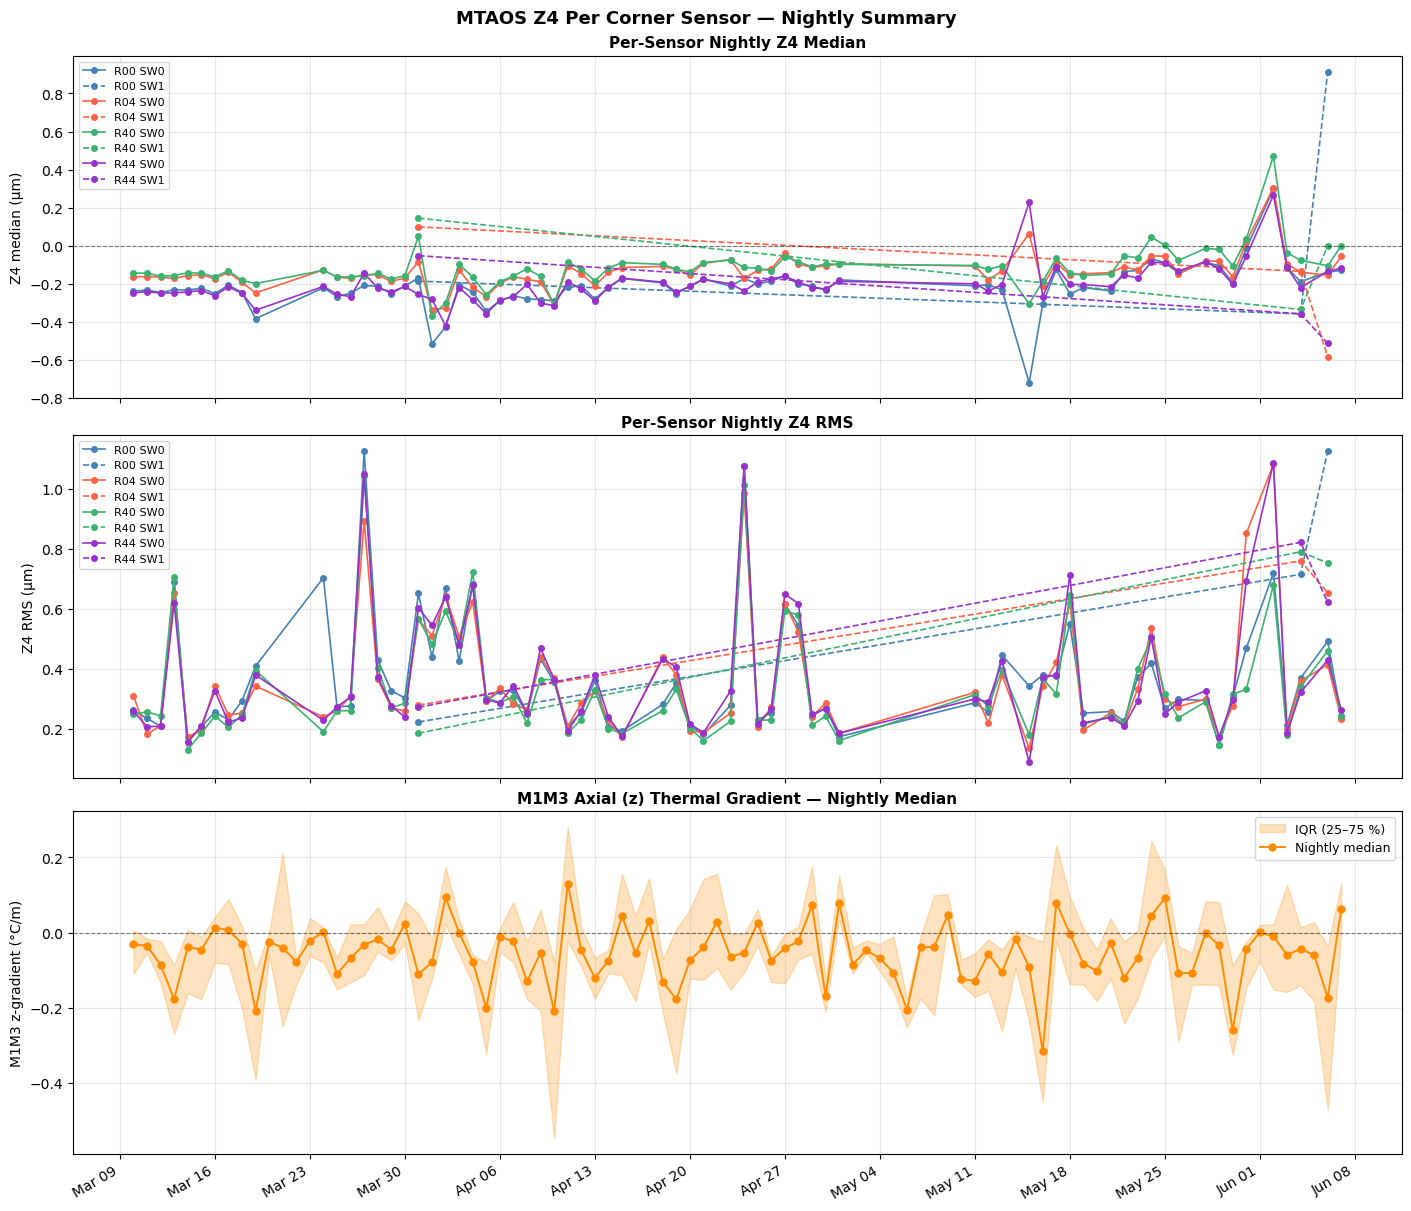

In [9]:
if df_wfe.empty:
    print("No data to plot.")
else:
    df_nightly_sensor = (
        df_wfe.groupby(["day_obs", "sensorId"])["z4_um"]
        .agg(z4_median="median", z4_rms="std", n="count")
        .reset_index()
    )
    df_nightly_sensor["date"] = pd.to_datetime(
        df_nightly_sensor["day_obs"].astype(str), format="%Y%m%d"
    )

    # ── Build nightly gradient summary if not already computed ──────────
    has_nightly_grad = 'df_grad' in globals() and df_grad is not None
    if has_nightly_grad and 'df_grad_nightly' not in globals():
        _dg = df_grad.copy()
        _ts = _dg.index
        if _ts.tzinfo is None:
            _ts = _ts.tz_localize('UTC')
        _dg['day_obs'] = (_ts - pd.Timedelta(hours=12)).strftime('%Y%m%d').astype(int)
        df_grad_nightly = (
            _dg.groupby('day_obs')['z_gradient']
            .agg(z_grad_median='median',
                 z_grad_q25=lambda x: x.quantile(0.25),
                 z_grad_q75=lambda x: x.quantile(0.75))
            .reset_index()
        )
        df_grad_nightly['date'] = pd.to_datetime(
            df_grad_nightly['day_obs'].astype(str), format='%Y%m%d'
        )

    nrows = 3 if has_nightly_grad else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(14, 4 * nrows),
                             sharex=True, constrained_layout=True)

    for ax, metric, ylabel, title in [
        (axes[0], "z4_median", "Z4 median (µm)", "Per-Sensor Nightly Z4 Median"),
        (axes[1], "z4_rms",    "Z4 RMS (µm)",    "Per-Sensor Nightly Z4 RMS"),
    ]:
        for sid in sorted(df_wfe["sensorId"].unique()):
            df_s = df_nightly_sensor[df_nightly_sensor["sensorId"] == sid]
            label = SENSOR_LABELS.get(int(sid), f"sensor {sid}")
            color = SENSOR_COLORS.get(int(sid), "gray")
            ls = SENSOR_LS.get(int(sid), "-")
            ax.plot(df_s["date"], df_s[metric], marker="o", ms=4, lw=1.2,
                    color=color, ls=ls, label=label)
        if metric == "z4_median":
            ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    if has_nightly_grad:
        ax = axes[2]
        ax.fill_between(df_grad_nightly['date'],
                        df_grad_nightly['z_grad_q25'], df_grad_nightly['z_grad_q75'],
                        alpha=0.25, color='darkorange', label='IQR (25–75 %)')
        ax.plot(df_grad_nightly['date'], df_grad_nightly['z_grad_median'],
                marker='o', ms=5, lw=1.4, color='darkorange', label='Nightly median')
        ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        ax.set_ylabel('M1M3 z-gradient (°C/m)')
        ax.set_title('M1M3 Axial (z) Thermal Gradient — Nightly Median',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.3)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.xticks(rotation=30, ha="right")
    fig.suptitle("MTAOS Z4 Per Corner Sensor — Nightly Summary",
                 fontsize=13, fontweight="bold")
    plt.show()


## 7. Z4 vs `aos_fwhm` — Exposure-Level Density Scatter

Join per-visit Z4 (averaged across the four corner sensors) to ConsDB
`aos_fwhm` using `visitId`.


In [10]:
if df_wfe.empty:
    print("No EFD data to join.")
else:
    df_z4_per_visit = (
        df_wfe.groupby("visitId")["z4_um"]
        .agg(z4_mean="mean", z4_std="std", z4_abs_mean=lambda x: x.abs().mean())
        .reset_index()
    )
    df_z4_per_visit["visitId"] = pd.to_numeric(df_z4_per_visit["visitId"], errors="coerce")
    df_consdb["visit_id"] = pd.to_numeric(df_consdb["visit_id"], errors="coerce")

    df_joined = df_z4_per_visit.merge(
        df_consdb[["visit_id", "day_obs", "obs_start", "aos_fwhm", "donut_blur_fwhm",
                   "psf_sigma_median", "seeing_zenith_500nm_median"]],
        left_on="visitId",
        right_on="visit_id",
        how="inner",
    )
    print(f"Matched visits: {len(df_joined)}")
    display(df_joined[["visitId", "z4_mean", "z4_std", "aos_fwhm"]].head(6))

Matched visits: 20399


,visitId,z4_mean,z4_std,aos_fwhm
0,2026031100014,-0.214411,0.103803,0.380317
1,2026031100015,-0.256697,0.093305,0.407420
2,2026031100016,-0.237563,0.057460,0.367806
3,2026031100017,-0.273849,0.069123,0.379583
4,2026031100018,-0.345497,0.106931,0.401870
5,2026031100019,-0.374707,0.091510,0.418535


## 8. M1M3 Thermal Gradients

Fetch M1M3 thermocouple data via `ThermocoupleAnalysis` (ts_m1m3_utils),
which reads `lsst.sal.ESS.temperature` scanner indices 114–117 and fits
linear planes across the 3-D sensor map to produce per-time-bin gradients:

| Column | Meaning |
|---|---|
| `z_gradient` | ∂T/∂z — axial (front-to-back) through-glass gradient (°C/m) |
| `radial_gradient` | ∂T/∂r — radial gradient across the mirror surface (°C/m) |
| `x_gradient` | ∂T/∂x — lateral gradient (°C/m) |
| `y_gradient` | ∂T/∂y — lateral gradient (°C/m) |

These are then joined to `df_joined` via `merge_asof` on `obs_start`.


In [6]:
import sys, importlib, pathlib as _pl

for _repo in ['ts_m1m3_utils', 'ts_salobj', 'ts_utils', 'ts_xml']:
    _p = f'/sdf/home/s/stalder/repos/lsst-ts/{_repo}/python'
    if _p not in sys.path:
        sys.path.insert(0, _p)

# lsst is a namespace package; extend its __path__ so subpackages added
# to sys.path after initial import are discoverable.
importlib.invalidate_caches()
import lsst.ts as _lsst_ts
_extra = [
    f'/sdf/home/s/stalder/repos/lsst-ts/{r}/python/lsst/ts'
    for r in ['ts_m1m3_utils', 'ts_salobj', 'ts_utils', 'ts_xml']
]
for _p in _extra:
    if _p not in list(_lsst_ts.__path__):
        _lsst_ts.__path__ = list(_lsst_ts.__path__) + [_p]

from lsst.ts.m1m3.utils import ThermocoupleAnalysis

_from_grad_cache = False
if not FORCE_REFETCH and _pl.Path(GRAD_CACHE_FILE).exists():
    df_grad = pd.read_parquet(GRAD_CACHE_FILE)
    if df_grad.index.tzinfo is None:
        df_grad.index = df_grad.index.tz_localize('UTC')
    _from_grad_cache = True
    print(f"\u2713 Loaded {len(df_grad)} gradient rows from cache: {GRAD_CACHE_FILE}")
    print(df_grad.describe().round(4))
else:
    _chunk_days = 5
    _step = TimeDelta(_chunk_days * u.day)
    _t = t_start
    _grad_chunks = []

    while _t < t_end:
        _t1 = min(_t + _step, t_end)
        print(f'  {_t.iso[:10]} -> {_t1.iso[:10]}...', end=' ', flush=True)
        try:
            _tc = ThermocoupleAnalysis(efd_client)
            await _tc.load(_t, _t1, time_bin=300)
            if _tc.xyz_r_gradients is not None and not _tc.xyz_r_gradients.empty:
                _grad_chunks.append(_tc.xyz_r_gradients[[
                    'z_gradient', 'radial_gradient', 'x_gradient', 'y_gradient'
                ]].copy())
                print(f'{len(_tc.xyz_r_gradients)} rows')
            else:
                print('no data')
        except Exception as e:
            print(f'ERROR: {e}')
        _t = _t1

    if _grad_chunks:
        df_grad = pd.concat(_grad_chunks).sort_index()
        if df_grad.index.tzinfo is None:
            df_grad.index = df_grad.index.tz_localize('UTC')
        df_grad = df_grad[~df_grad.index.duplicated(keep='last')]
        print(f'Total gradient rows: {len(df_grad)}')
        print(df_grad.describe().round(4))
        df_grad.to_parquet(GRAD_CACHE_FILE)
        print(f"\u2713 Saved {len(df_grad)} gradient rows \u2192 {GRAD_CACHE_FILE}")
    else:
        print('No M1M3 gradient data returned.')
        df_grad = None


/sdf/home/s/stalder/.local/lib/python3.13/site-packages/authlib/_joserfc_helpers.py:8: AuthlibDeprecationWarning: authlib.jose module is deprecated, please use joserfc instead.
It will be compatible before version 2.0.0.
  from authlib.jose import ECKey


✓ Loaded 25920 gradient rows from cache: ../data/z4_m1m3_gradients.parquet
       z_gradient  radial_gradient  x_gradient  y_gradient
count  24443.0000       24443.0000  24443.0000  24443.0000
mean      -0.0570          -0.0185      0.0024     -0.0252
std        0.1646           0.0485      0.0110      0.0317
min       -0.7764          -0.2251     -0.0387     -0.2394
25%       -0.1413          -0.0345     -0.0038     -0.0391
50%       -0.0480          -0.0150      0.0001     -0.0185
75%        0.0198           0.0041      0.0060     -0.0084
max        1.0385           0.1993      0.0638      0.0731


In [11]:
if df_grad is not None and 'df_joined' in globals() and not df_joined.empty:
    # Normalize obs_start to UTC-aware, handling both naive and aware
    obs_raw = pd.to_datetime(df_joined['obs_start'])
    if obs_raw.dt.tz is None:
        obs = obs_raw.dt.tz_localize('UTC')
    else:
        obs = obs_raw.dt.tz_convert('UTC')

    # Normalize df_grad index to UTC-aware
    grad_ts = df_grad.index
    if grad_ts.tzinfo is None:
        df_grad.index = grad_ts.tz_localize('UTC')
    else:
        df_grad.index = grad_ts.tz_convert('UTC')

    df_grad_reset = df_grad.reset_index()
    ts_col = df_grad_reset.columns[0]
    df_grad_reset = df_grad_reset.rename(columns={ts_col: 'ts'}).sort_values('ts')
    df_grad_reset['ts'] = pd.to_datetime(df_grad_reset['ts'], utc=True)

    df_obs = pd.DataFrame({'ts': pd.to_datetime(obs.values, utc=True),
                           'row_idx': range(len(df_joined))})
    df_obs = df_obs.sort_values('ts')

    merged = pd.merge_asof(
        df_obs, df_grad_reset,
        on='ts', direction='nearest',
        tolerance=pd.Timedelta('15min'),
    )
    merged = merged.set_index('row_idx').reindex(range(len(df_joined)))

    for col in ['z_gradient', 'radial_gradient', 'x_gradient', 'y_gradient']:
        df_joined[col] = merged[col].values

    n_matched = df_joined['z_gradient'].notna().sum()
    print(f'Gradient matched to {n_matched}/{len(df_joined)} visits '
          f'({100*n_matched/len(df_joined):.1f}%)')
    print(df_joined[['z_gradient','radial_gradient','x_gradient','y_gradient']].describe().round(4))
else:
    print('Skipping gradient join — no gradient data or df_joined not available.')

Gradient matched to 20192/20399 visits (99.0%)
       z_gradient  radial_gradient  x_gradient  y_gradient
count  20192.0000       20192.0000  20192.0000  20192.0000
mean      -0.0909          -0.0209      0.0016     -0.0179
std        0.1747           0.0281      0.0079      0.0216
min       -0.7633          -0.1945     -0.0174     -0.1096
25%       -0.1972          -0.0254     -0.0026     -0.0223
50%       -0.0838          -0.0175     -0.0001     -0.0122
75%        0.0219          -0.0093      0.0030     -0.0065
max        0.6706           0.0817      0.0458      0.0264


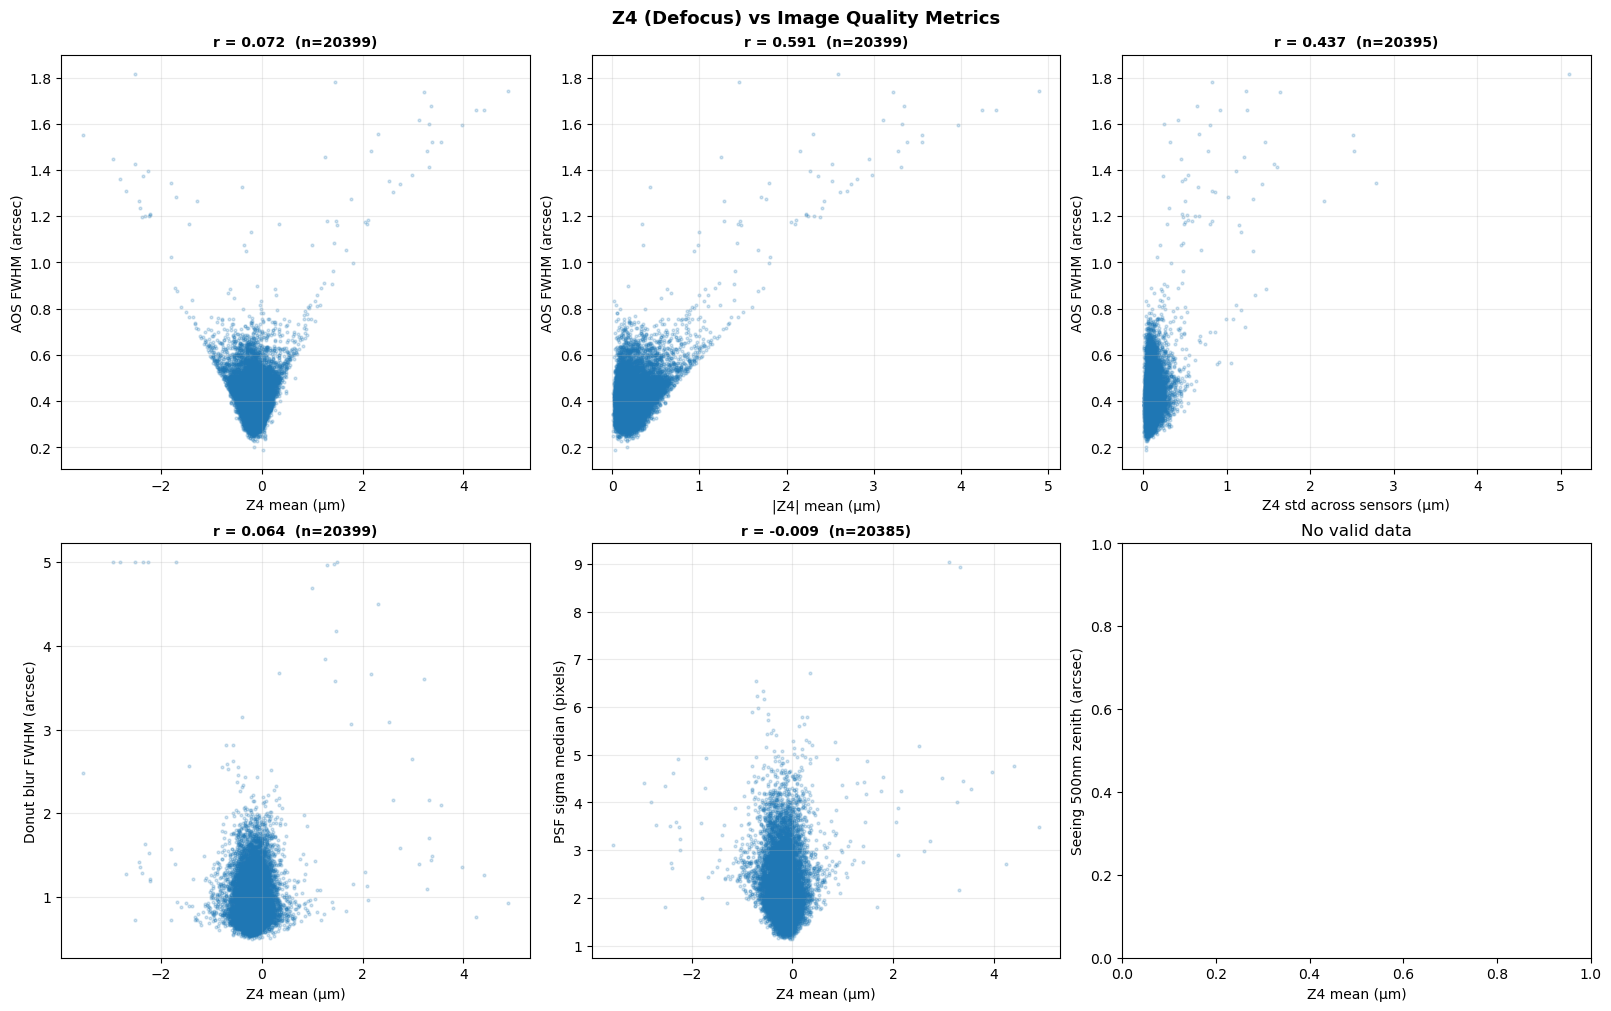

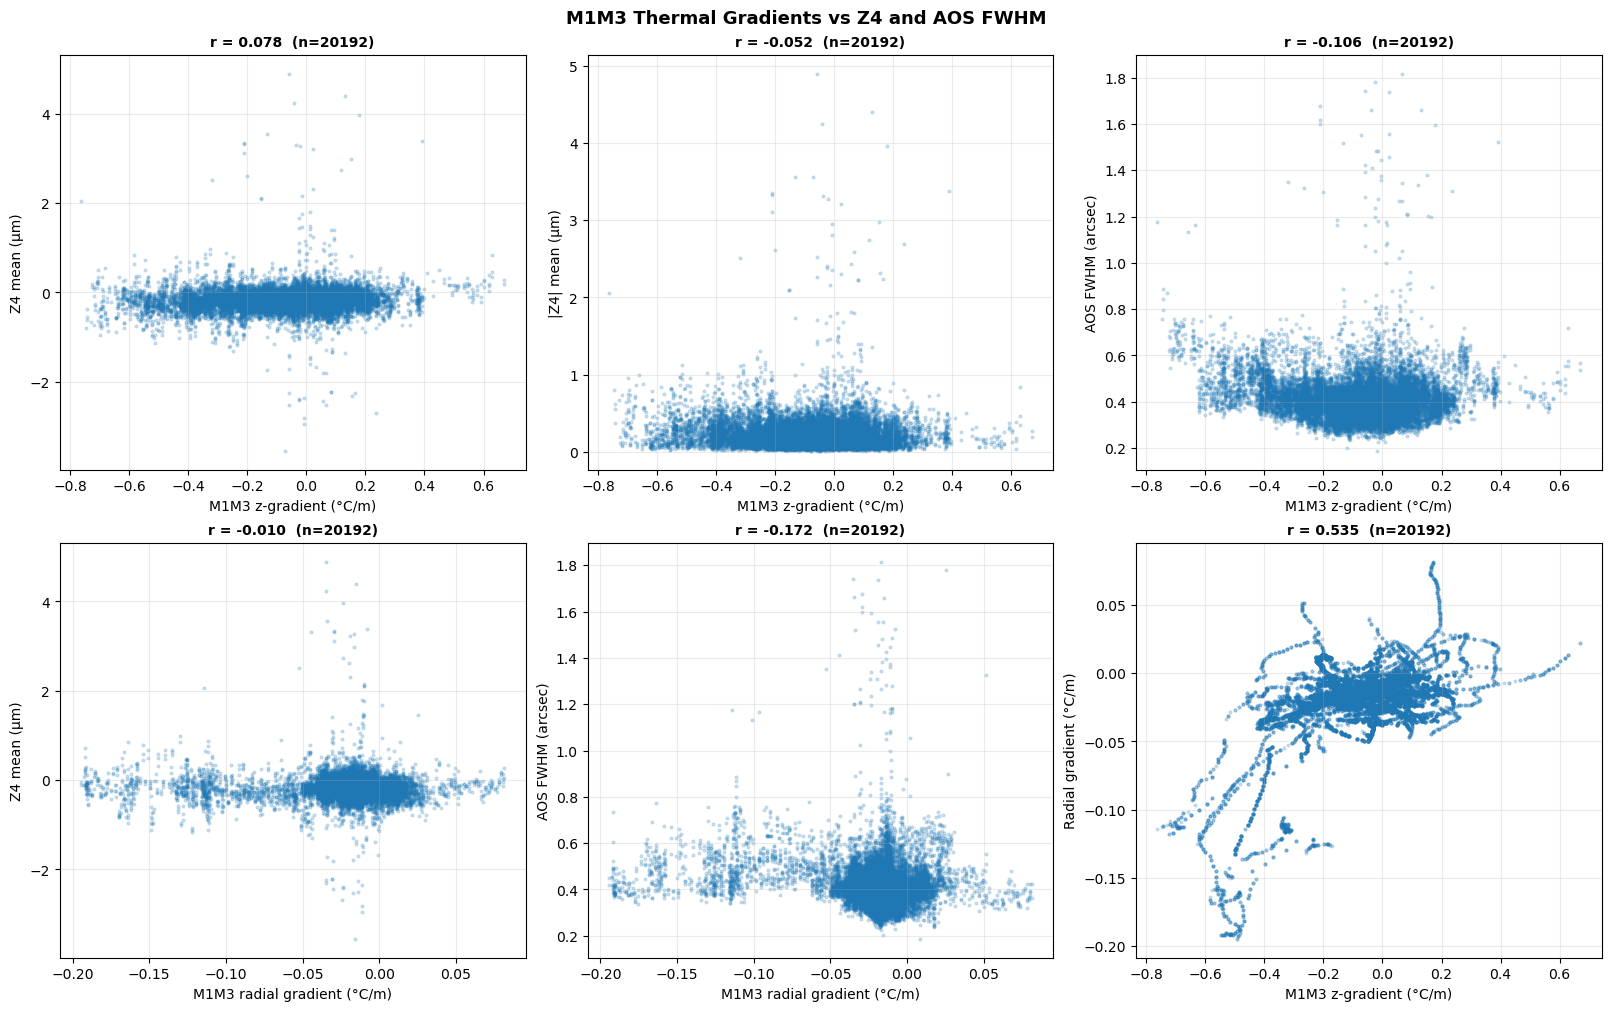


Correlation summary:
  z4_mean                vs aos_fwhm                        r= 0.0718  n=20399
  z4_abs_mean            vs aos_fwhm                        r= 0.5912  n=20399
  z4_std                 vs aos_fwhm                        r= 0.4370  n=20395
  z4_mean                vs donut_blur_fwhm                 r= 0.0639  n=20399
  z4_mean                vs psf_sigma_median                r=-0.0087  n=20385
  z_gradient             vs z4_mean                         r= 0.0783  n=20192
  z_gradient             vs z4_abs_mean                     r=-0.0517  n=20192
  z_gradient             vs aos_fwhm                        r=-0.1059  n=20192
  radial_gradient        vs z4_mean                         r=-0.0097  n=20192
  radial_gradient        vs aos_fwhm                        r=-0.1722  n=20192
  z_gradient             vs radial_gradient                 r= 0.5354  n=20192


In [12]:
if 'df_joined' not in globals() or df_joined.empty:
    print('No joined data to plot.')
else:
    has_grad = 'z_gradient' in df_joined.columns and df_joined['z_gradient'].notna().any()

    # ── Panel 1: Z4 vs IQ metrics (same as before + gradients if available) ──
    plot_pairs_iq = [
        ('z4_mean',     'aos_fwhm',                 'Z4 mean (µm)',                  'AOS FWHM (arcsec)'),
        ('z4_abs_mean', 'aos_fwhm',                 '|Z4| mean (µm)',                'AOS FWHM (arcsec)'),
        ('z4_std',      'aos_fwhm',                 'Z4 std across sensors (µm)',    'AOS FWHM (arcsec)'),
        ('z4_mean',     'donut_blur_fwhm',           'Z4 mean (µm)',                  'Donut blur FWHM (arcsec)'),
        ('z4_mean',     'psf_sigma_median',          'Z4 mean (µm)',                  'PSF sigma median (pixels)'),
        ('z4_mean',     'seeing_zenith_500nm_median','Z4 mean (µm)',                  'Seeing 500nm zenith (arcsec)'),
    ]

    def _scatter_grid(pairs, df_input, suptitle):
        ncols = 3
        nrows = (len(pairs) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows), constrained_layout=True)
        axes = np.array(axes).ravel()
        for ax, (x_col, y_col, x_lab, y_lab) in zip(axes, pairs):
            valid = df_input[[x_col, y_col]].dropna()
            if len(valid) == 0:
                ax.set_title('No valid data'); ax.set_xlabel(x_lab); ax.set_ylabel(y_lab)
                continue
            ax.scatter(valid[x_col], valid[y_col], s=4, alpha=0.2, color='tab:blue', rasterized=True)
            r = valid[x_col].corr(valid[y_col])
            ax.set_title(f'r = {r:.3f}  (n={len(valid)})', fontsize=10, fontweight='bold')
            ax.set_xlabel(x_lab); ax.set_ylabel(y_lab)
            ax.grid(alpha=0.25, zorder=0)
        for ax in axes[len(pairs):]:
            ax.axis('off')
        fig.suptitle(suptitle, fontsize=13, fontweight='bold')
        plt.show()

    _scatter_grid(
        plot_pairs_iq, df_joined,
        'Z4 (Defocus) vs Image Quality Metrics'
    )

    if has_grad:
        plot_pairs_grad = [
            ('z_gradient',      'z4_mean',     'M1M3 z-gradient (°C/m)',      'Z4 mean (µm)'),
            ('z_gradient',      'z4_abs_mean', 'M1M3 z-gradient (°C/m)',      '|Z4| mean (µm)'),
            ('z_gradient',      'aos_fwhm',    'M1M3 z-gradient (°C/m)',      'AOS FWHM (arcsec)'),
            ('radial_gradient', 'z4_mean',     'M1M3 radial gradient (°C/m)', 'Z4 mean (µm)'),
            ('radial_gradient', 'aos_fwhm',    'M1M3 radial gradient (°C/m)', 'AOS FWHM (arcsec)'),
            ('z_gradient',      'radial_gradient', 'M1M3 z-gradient (°C/m)', 'Radial gradient (°C/m)'),
        ]
        _scatter_grid(
            plot_pairs_grad, df_joined,
            'M1M3 Thermal Gradients vs Z4 and AOS FWHM'
        )
    else:
        print('M1M3 gradient columns not available — skipping gradient scatter plots.')

    print('\nCorrelation summary:')
    all_pairs = plot_pairs_iq + (plot_pairs_grad if has_grad else [])
    for x_col, y_col, x_lab, y_lab in all_pairs:
        valid = df_joined[[x_col, y_col]].dropna()
        if len(valid) == 0: continue
        r = valid[x_col].corr(valid[y_col])
        print(f'  {x_col:22s} vs {y_col:30s}  r={r:7.4f}  n={len(valid)}')

## Summary

- **Z4 timeline**: nightly median and IQR show long-term focus trends and
  any systematic offsets across the observing season.
- **Z4 RMS**: intra-night spread indicates nights with poor focus stability.
- **Per-sensor comparison**: divergence between the four corner sensors can
  indicate tilts or astigmatic focus errors rather than pure defocus.
- **Z4 vs AOS FWHM**: a strong positive correlation between |Z4| and
  `aos_fwhm` would confirm that residual defocus is the dominant AOS FWHM
  driver; a weak correlation points to other aberrations (e.g. Z5/Z6
  astigmatism, coma) or atmospheric seeing as the limiting factor.
